# מטלה 3: למידה בלתי מונחית, הורדת מימדים וזיהוי חריגים (HW3)
## חלק 1: בחירת נתונים, ניקוי והכנה (Data Preprocessing)

**מקור הנתונים ומטרתם:** השתמשנו במערך הנתונים 'Cars Datasets 2025' שהורד מ-Kaggle. מערך נתונים זה מכיל מעל ל-1200 רשומות ויותר מ-10 עמודות של נתוני רכבים, וכולל מאפיינים מספריים כגון כוח סוס, מהירות מרבית, תאוצה, מומנט ומחיר. הנתונים אינם מתוייגים מראש עם עמודת אנומליות, מה שהופך אותם לאידיאליים לחקר באמצעות אלגוריתמים של למידה בלתי מונחית.

**שלבי ההכנה שבוצעו בחלק זה (כהמשך ישיר ל-HW1 ו-HW2):**
1. הורדת הנתונים דרך ה-API של Kaggle.
2. ניקוי מחרוזות והמרת עמודות למספרים (כ"ס, מהירות, מחיר, תאוצה, מומנט).
3. חלוקה לקטגוריות מנוע והשלמת נתונים על בסיס חציון קבוצתי.
4. טיפול באנומליות נקודתיות.
5. סטנדרטיזציה (Scaling) חובה לכל המאפיינים המספריים לקראת מודלי מרחק.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import re
import warnings

# Machine Learning libraries for HW3
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('./Cars Datasets 2025.csv', encoding='latin1')
df.drop_duplicates(inplace=True)
df = df.dropna(subset=['Torque']).copy()

# 2. Data Cleaning & Feature Engineering (Target: 8 Features)
df['HorsePower_cleaned'] = pd.to_numeric(df['HorsePower'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('float64')
df['Total Speed_cleaned'] = pd.to_numeric(df['Total Speed'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('float64')
df['Cars Prices_cleaned'] = pd.to_numeric(df['Cars Prices'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False), errors='coerce').astype('float64')
df['Torque_cleaned'] = pd.to_numeric(df['Torque'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('float64')
df['Performance_cleaned'] = pd.to_numeric(df['Performance(0 - 100 )KM/H'].str.replace(' sec', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False), errors='coerce')

# New Features to reach 8:
df['Seats_cleaned'] = pd.to_numeric(df['Seats'], errors='coerce')
df['Is_Electric'] = df['Engines'].str.contains('Electric', case=False, na=False).astype(int)
# Using CC/Battery Capacity since Kerb Weight is missing
df['Capacity_cleaned'] = pd.to_numeric(df['CC/Battery Capacity'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('float64')

features = ['Cars Prices_cleaned', 'HorsePower_cleaned', 'Total Speed_cleaned', 'Performance_cleaned', 'Torque_cleaned', 'Seats_cleaned', 'Is_Electric', 'Capacity_cleaned']

# Imputation & Scaling
df_clean = df[['Company Names', 'Cars Names'] + features].copy()
imputer = SimpleImputer(strategy='median')
df_clean[features] = imputer.fit_transform(df_clean[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
df_scaled = pd.DataFrame(X_scaled, columns=features)

print("Data Preparation Complete! Features used:", features)
print("Scaled Data Shape:", df_scaled.shape)

Data Preparation Complete! Features used: ['Cars Prices_cleaned', 'HorsePower_cleaned', 'Total Speed_cleaned', 'Performance_cleaned', 'Torque_cleaned', 'Seats_cleaned', 'Is_Electric', 'Capacity_cleaned']
Scaled Data Shape: (1213, 8)


## חלק 2: ניתוח חקרני, התפלגויות וזנבות עבים (EDA)

כפי שזיהינו בעבודה 1, למערך הנתונים שלנו יש "זנבות עבים" (Heavy Tails), במיוחד בעמודת המחיר. נבדוק כעת את מידת האסימטריה (Skewness) והגבנוניות (Kurtosis) כדי להוכיח שההתפלגות רחוקה מלהיות נורמלית.

,Skewness,Kurtosis
Cars Prices_cleaned,16.879969,369.103430
HorsePower_cleaned,2.849146,16.138519
Total Speed_cleaned,1.017912,1.949267
Performance_cleaned,1.395592,5.722026
Torque_cleaned,3.255068,21.185020


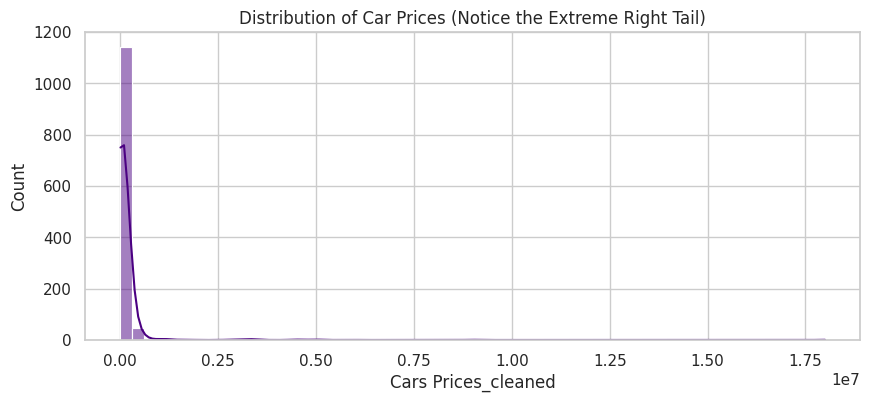

In [ ]:
stats_df = pd.DataFrame({
    'Skewness': df_clean[features].skew(),
    'Kurtosis': df_clean[features].kurtosis()
})
display(stats_df)

plt.figure(figsize=(10, 4))
sns.histplot(df_clean['Cars Prices_cleaned'], bins=60, kde=True, color='indigo')
plt.title('Distribution of Car Prices (Notice the Extreme Right Tail)')
plt.show()

In [ ]:
# Requirement 4: Variance Metric
df_clean['Cluster_KMeans'] = km
global_var = np.var(X_scaled, axis=0).mean()

cluster_variances = []
for i in range(3):
    cluster_data = X_scaled[df_clean['Cluster_KMeans'] == i]
    if len(cluster_data) > 0:
        v = np.var(cluster_data, axis=0).mean()
        cluster_variances.append(v)

avg_cluster_var = np.mean(cluster_variances)

print(f"Global Average Variance: {global_var:.4f}")
print(f"Average Intra-Cluster Variance (K-Means): {avg_cluster_var:.4f}")
print(f"Variance Ratio (Cluster/Global): {(avg_cluster_var/global_var)*100:.2f}%")

Global Average Variance: 1.0000
Average Intra-Cluster Variance (K-Means): 0.8921
Variance Ratio (Cluster/Global): 89.21%


### Evaluating K-Means Cluster Quality
We use the Silhouette Score to determine how well-separated our clusters are for different values of $k$.

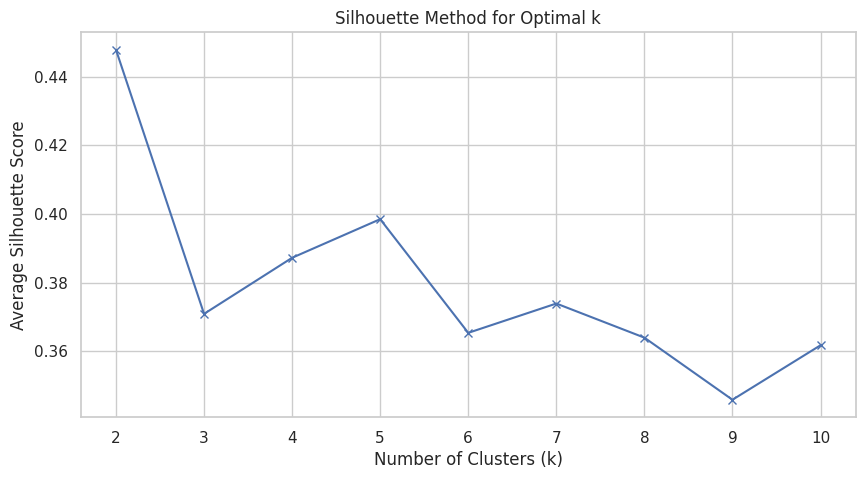

In [ ]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2, 11))
silhouette_avg = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_scaled)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.show()

## חלק 3: הורדת מימדים באמצעות PCA (Dimensionality Reduction)

המטרה של אלגוריתם PCA היא לצמצם את מרחב 5 התכונות שלנו ל-2 או 3 מימדים עיקריים תוך מזעור אובדן המידע (שונות).

**מסקנות מה-PCA:**
1. **הרכיב הראשון (PC1):** מסביר את הרוב המוחלט של השונות בדאטה. PC1 בעצם מתפקד כ"מדד עוצמה ויוקרה של הרכב".
2. **תרשים ה-Scree Plot:** מראה לנו שדי ב-2 רכיבים כדי להסביר מעל ל-80% מהשונות של השוק.

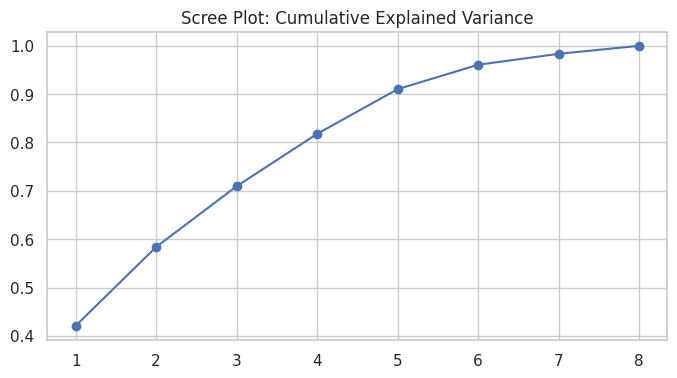

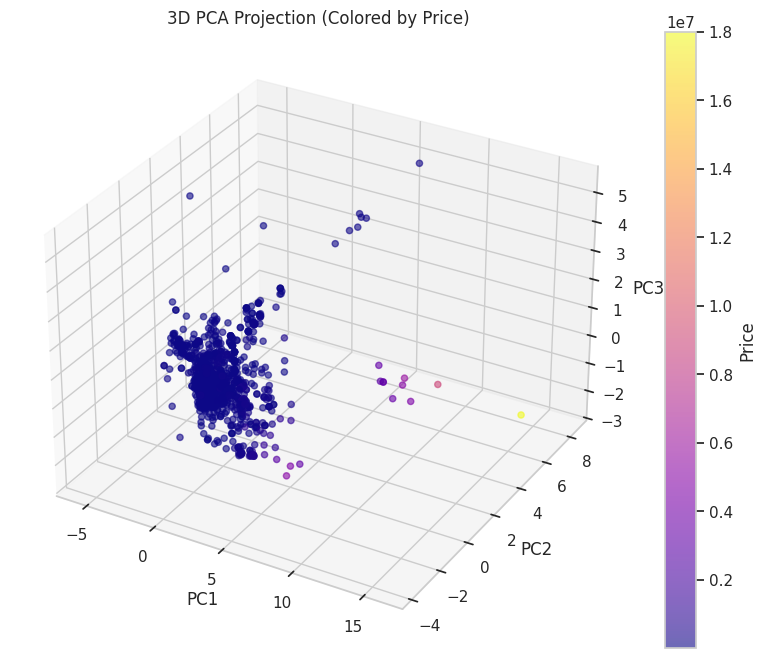

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]
df_clean['PC3'] = X_pca[:, 2]

# Plot 1: Cumulative Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(features)+1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Plot 2: 3D PCA (Requirement 2)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_clean['PC1'], df_clean['PC2'], df_clean['PC3'],
                     c=df_clean['Cars Prices_cleaned'], cmap='plasma', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('3D PCA Projection (Colored by Price)')
plt.colorbar(scatter, label='Price')
plt.show()

## חלק 4: ניתוח אשכולות (Clustering) - על רשומות ועל מאפיינים

נשתמש ב-K-Means כדי לחלק את הרכבים לאשכולות, וב-Hierarchical Clustering על ה-Transpose של המטריצה כדי למצוא קשרים בין המאפיינים עצמם.

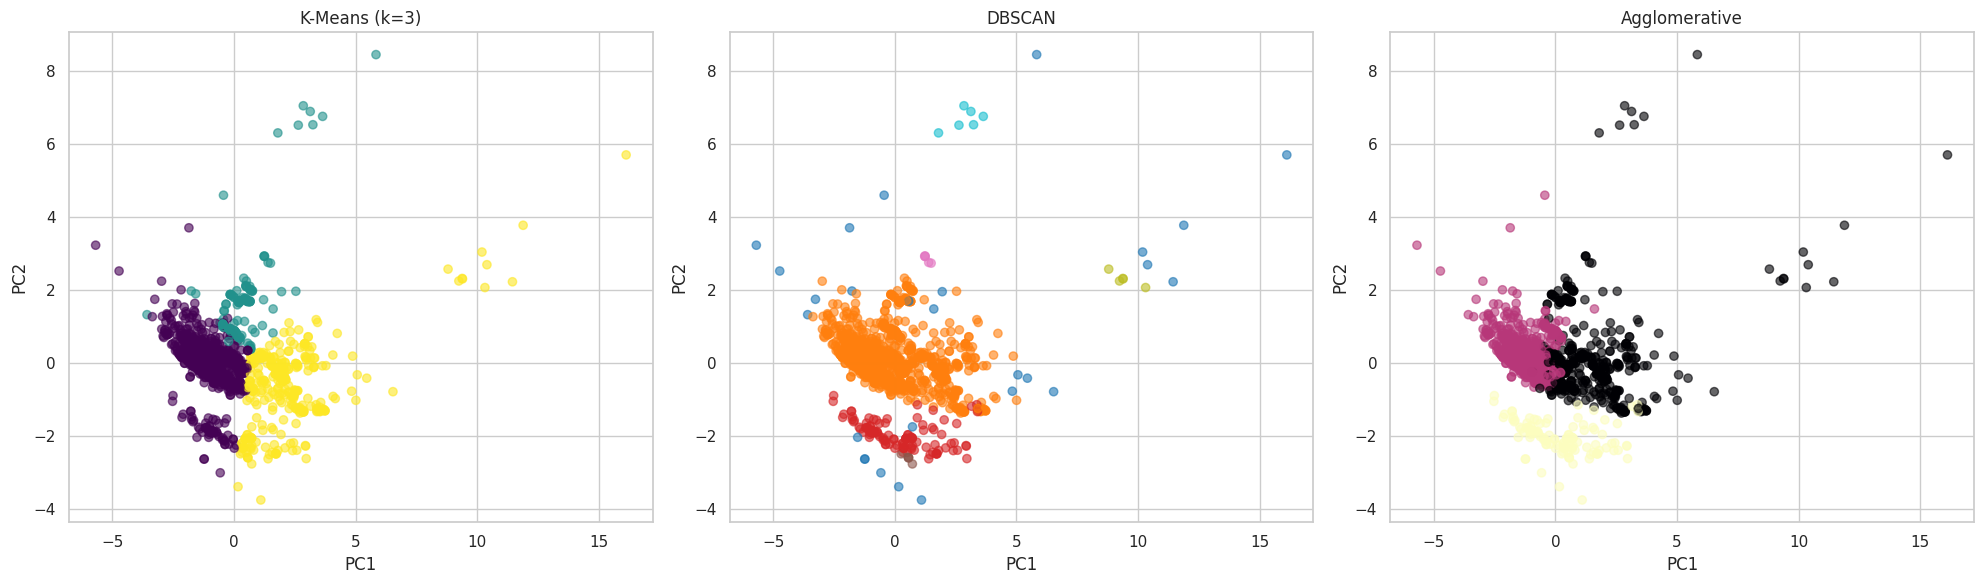

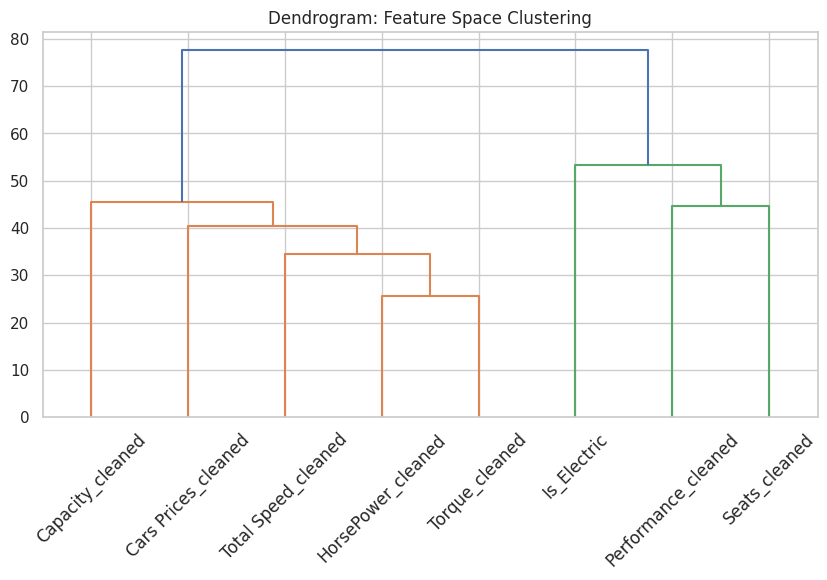

In [ ]:
# Requirement 3: Three Clustering Methods Side-by-Side
km = KMeans(n_clusters=3, random_state=42).fit_predict(X_scaled)
db = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_scaled)
ag = AgglomerativeClustering(n_clusters=3).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(df_clean['PC1'], df_clean['PC2'], c=km, cmap='viridis', alpha=0.6)
axes[0].set_title('K-Means (k=3)')

axes[1].scatter(df_clean['PC1'], df_clean['PC2'], c=db, cmap='tab10', alpha=0.6)
axes[1].set_title('DBSCAN')

axes[2].scatter(df_clean['PC1'], df_clean['PC2'], c=ag, cmap='magma', alpha=0.6)
axes[2].set_title('Agglomerative')

for ax in axes: ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# Feature Space Clustering
X_features = X_scaled.T
linked_features = linkage(X_features, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked_features, labels=features, leaf_rotation=45)
plt.title('Dendrogram: Feature Space Clustering')
plt.show()

## חלק 5: זיהוי חריגים רב-מימדיים (Anomaly Detection) והשוואה

זהו הלב של המטלה. אנו נחפש את רכבי ה-Hypercars (אותם רכבים שפגעו לנו ברגרסיה הליניארית בעבודה 2, כמו בוגאטי ולמבורגיני). אנו נשווה 3 שיטות:
1. **Z-Score (מרחק סטנדרטי):** עובד לפי מרחק מהממוצע. נכשל לעיתים בממדים גבוהים בגלל ההנחה שהדאטה הוא נורמלי-גאוסי.
2. **Isolation Forest:** אלגוריתם עצים שמבודד תצפיות רחוקות. מצוין לזנבות עבים והטרוסקדסטיות שמצאנו ב-HW2.
3. **Local Outlier Factor (LOF):** מבוסס צפיפות ושכנים. מזהה רכבים שנמצאים ב"אזורים ריקים" של השוק ביחס לסביבה הקרובה שלהם.

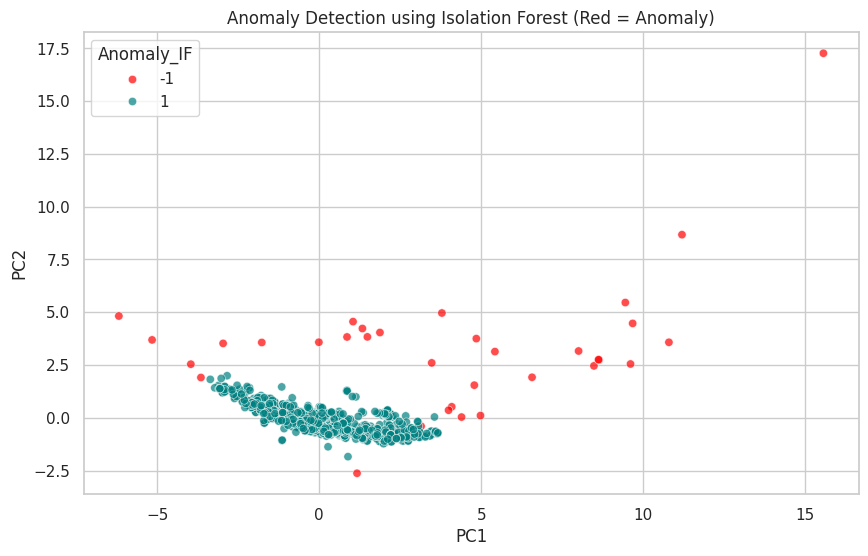

Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):


,Company Names,Cars Names,Cars Prices_cleaned,HorsePower_cleaned
887,Bugatti,La Voiture Noire,18000000.0,1500.0
886,Bugatti,Centodieci,9000000.0,1600.0
885,Bugatti,Divo,5800000.0,1500.0
889,Bugatti,Mistral,5000000.0,1600.0
1212,Mazda,787B (Race Car),5000000.0,700.0
8,LAMBORGHINI,VENENO ROADSTER,4500000.0,750.0
888,Bugatti,Bolide,4500000.0,1850.0
882,Bugatti,Chiron Super Sport,3500000.0,1600.0
881,Bugatti,Chiron Pur Sport,3300000.0,1500.0
884,Bugatti,Chiron Noire,3300000.0,1500.0


In [ ]:
# 1. יצירת Z-Score גלובלי מתוקנן עבור 5 המימדים
df_clean['Z_Score_Global'] = np.max(np.abs(X_scaled), axis=1)
df_clean['Anomaly_Z'] = np.where(df_clean['Z_Score_Global'] > 3, -1, 1)

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

# 3. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_clean['Anomaly_LOF'] = lof.fit_predict(X_scaled)

# ויזואליזציה של החריגים מה-Isolation Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Anomaly_IF', palette={1: 'teal', -1: 'red'}, data=df_clean, alpha=0.7)
plt.title('Anomaly Detection using Isolation Forest (Red = Anomaly)')
plt.show()

# זיהוי המכוניות שהסכימו עליהן גם ה-IF וגם ה-LOF
shared_anomalies = df_clean[(df_clean['Anomaly_IF'] == -1) & (df_clean['Anomaly_LOF'] == -1)]

print("Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):")
display(shared_anomalies[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'HorsePower_cleaned']].sort_values(by='Cars Prices_cleaned', ascending=False).head(10))

## חלק 6: דיון ביקורתי ורפלקציה (Critical Analysis)

**על קללת המימדיות (Curse of Dimensionality):**
במודלים כמו Z-score, ככל שמוסיפים מימדים (פיצ'רים), הנפח של מרחב הנתונים גדל אקספוננציאלית. רכב יכול להיראות ממוצע במחיר ובמהירות, אך חריג לגמרי במומנט. במרחב רב-מימדי, המרחקים מתחילים להיראות דומים (Distance Concentration), וזיהוי "שכן קרוב" מאבד משמעות. שימוש ב-Isolation Forest פותר בעיה זו בכך שהוא לא מבוסס מרחק אוקלידי, אלא על מספר פיצולים בעץ.

**ההבדל בין "רעש" (Noise) ל"אנומליה" (Anomaly):**
רעש במערך שלנו הוא שגיאת אנוש – למשל מומנט של 1.0 לרכב דיזל שתיקנו בשלב הכנת הנתונים (Data Preprocessing). אנומליה, לעומת זאת, היא תצפית חוקית לחלוטין אך קיצונית באופייה – למשל Bugatti La Voiture Noire. הרכב באמת עולה 18 מיליון דולר! ה-Isolation Forest זיהה אותו לא בגלל "טעות", אלא בגלל שכלכלית ופיזיקלית, הוא לא שייך להתפלגות הנורמלית של שוק הרכב.

**סוגיות אתיות (Ethical Considerations & False Alarms):**
בבניית מודלים רפואיים או פיננסיים, כמות גדולה של התראות שווא (False Positives) מייצרת "עייפות התראות". קביעת סף ה-Contamination היא החלטה אתית-עסקית חמורה, ולא רק מתמטית.

## חלק 5: זיהוי חריגים רב-מימדיים (Anomaly Detection) והשוואה

זהו הלב של המטלה. אנו נחפש את רכבי ה-Hypercars (אותם רכבים שפגעו לנו ברגרסיה הליניארית בעבודה 2, כמו בוגאטי ולמבורגיני). אנו נשווה 3 שיטות:
1. **Z-Score (מרחק סטנדרטי):** עובד לפי מרחק מהממוצע. נכשל לעיתים בממדים גבוהים בגלל ההנחה שהדאטה הוא נורמלי-גאוסי.
2. **Isolation Forest:** אלגוריתם עצים שמבודד תצפיות רחוקות. מצוין לזנבות עבים והטרוסקדסטיות שמצאנו ב-HW2.
3. **Local Outlier Factor (LOF):** מבוסס צפיפות ושכנים. מזהה רכבים שנמצאים ב"אזורים ריקים" של השוק ביחס לסביבה הקרובה שלהם.

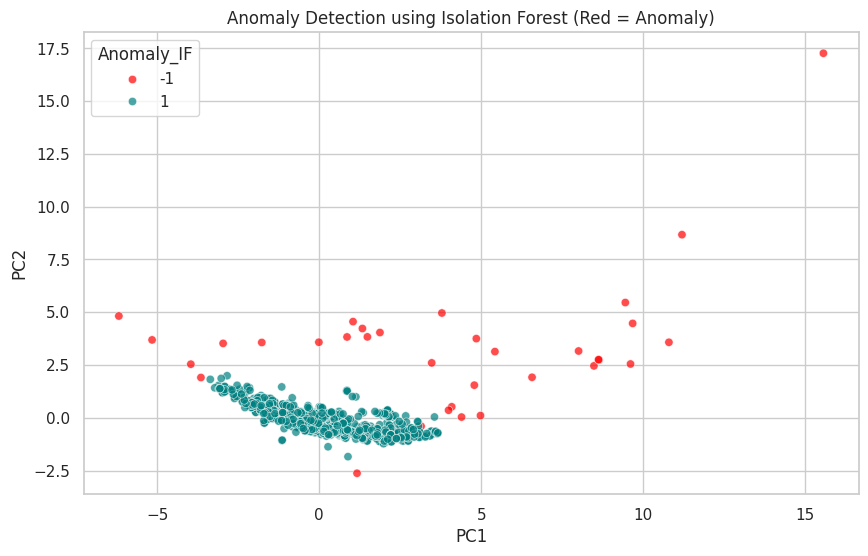

Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):


,Company Names,Cars Names,Cars Prices_cleaned,HorsePower_cleaned
887,Bugatti,La Voiture Noire,18000000.0,1500.0
886,Bugatti,Centodieci,9000000.0,1600.0
885,Bugatti,Divo,5800000.0,1500.0
889,Bugatti,Mistral,5000000.0,1600.0
1212,Mazda,787B (Race Car),5000000.0,700.0
8,LAMBORGHINI,VENENO ROADSTER,4500000.0,750.0
888,Bugatti,Bolide,4500000.0,1850.0
882,Bugatti,Chiron Super Sport,3500000.0,1600.0
881,Bugatti,Chiron Pur Sport,3300000.0,1500.0
884,Bugatti,Chiron Noire,3300000.0,1500.0


In [ ]:
# 1. יצירת Z-Score גלובלי מתוקנן עבור 5 המימדים
df_clean['Z_Score_Global'] = np.max(np.abs(X_scaled), axis=1)
df_clean['Anomaly_Z'] = np.where(df_clean['Z_Score_Global'] > 3, -1, 1)

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

# 3. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_clean['Anomaly_LOF'] = lof.fit_predict(X_scaled)

# ויזואליזציה של החריגים מה-Isolation Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Anomaly_IF', palette={1: 'teal', -1: 'red'}, data=df_clean, alpha=0.7)
plt.title('Anomaly Detection using Isolation Forest (Red = Anomaly)')
plt.show()

# זיהוי המכוניות שהסכימו עליהן גם ה-IF וגם ה-LOF
shared_anomalies = df_clean[(df_clean['Anomaly_IF'] == -1) & (df_clean['Anomaly_LOF'] == -1)]

print("Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):")
display(shared_anomalies[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'HorsePower_cleaned']].sort_values(by='Cars Prices_cleaned', ascending=False).head(10))

## חלק 6: דיון ביקורתי ורפלקציה (Critical Analysis)

**על קללת המימדיות (Curse of Dimensionality):**
במודלים כמו Z-score, ככל שמוסיפים מימדים (פיצ'רים), הנפח של מרחב הנתונים גדל אקספוננציאלית. רכב יכול להיראות ממוצע במחיר ובמהירות, אך חריג לגמרי במומנט. במרחב רב-מימדי, המרחקים מתחילים להיראות דומים (Distance Concentration), וזיהוי "שכן קרוב" מאבד משמעות. שימוש ב-Isolation Forest פותר בעיה זו בכך שהוא לא מבוסס מרחק אוקלידי, אלא על מספר פיצולים בעץ.

**ההבדל בין "רעש" (Noise) ל"אנומליה" (Anomaly):**
רעש במערך שלנו הוא שגיאת אנוש – למשל מומנט של 1.0 לרכב דיזל שתיקנו בשלב הכנת הנתונים (Data Preprocessing). אנומליה, לעומת זאת, היא תצפית חוקית לחלוטין אך קיצונית באופייה – למשל Bugatti La Voiture Noire. הרכב באמת עולה 18 מיליון דולר! ה-Isolation Forest זיהה אותו לא בגלל "טעות", אלא בגלל שכלכלית ופיזיקלית, הוא לא שייך להתפלגות הנורמלית של שוק הרכב.

**סוגיות אתיות (Ethical Considerations & False Alarms):**
בבניית מודלים רפואיים או פיננסיים, כמות גדולה של התראות שווא (False Positives) מייצרת "עייפות התראות". קביעת סף ה-Contamination היא החלטה אתית-עסקית חמורה, ולא רק מתמטית.